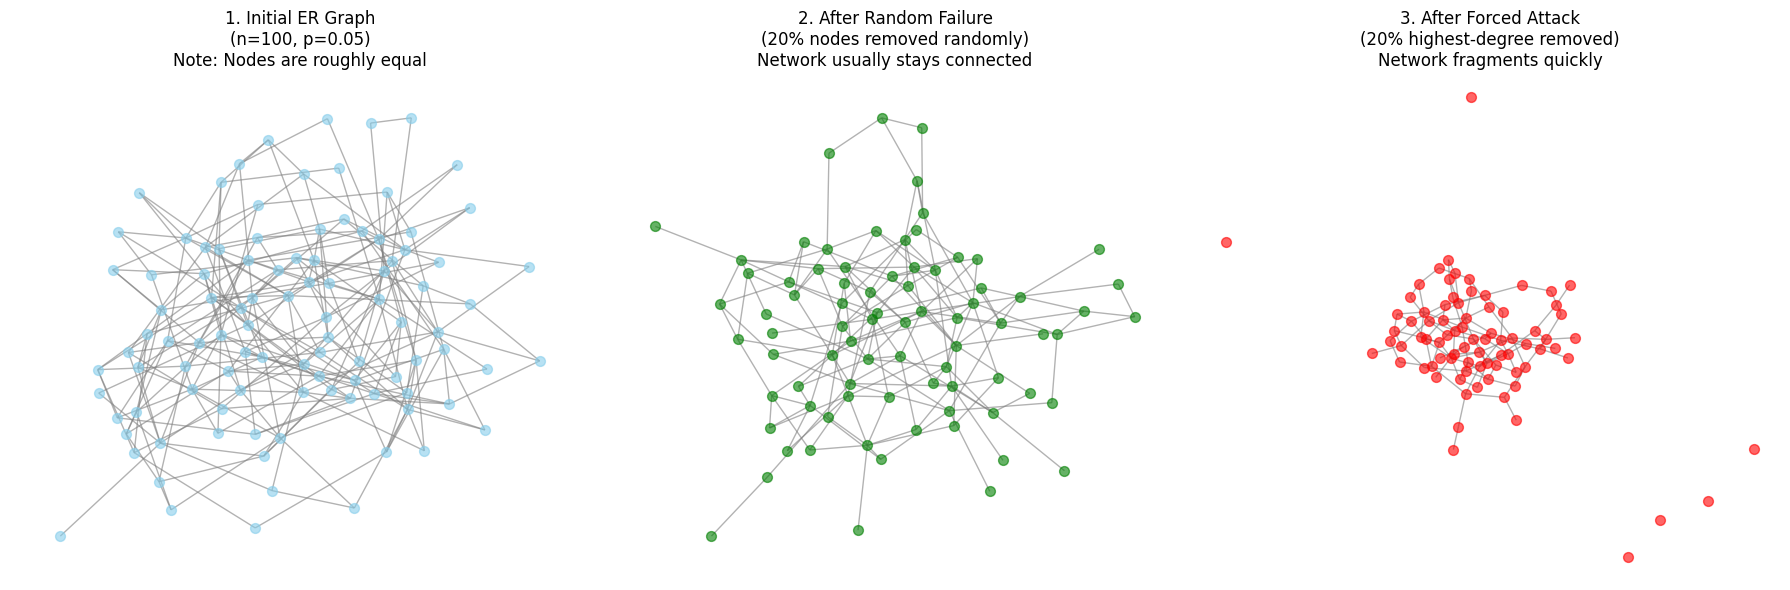

Giant Component Size (Initial): 100
Giant Component Size (Random Failure): 80
Giant Component Size (Forced Attack): 74


In [1]:
import random
import networkx as nx
import matplotlib.pyplot as plt

def create_er_graph(n, p):
    """
    Implements the Erdős-Rényi Model (G(n, p)).
    Step 1: Take n (nodes) and p (probability)
    Step 2: Create an empty graph and add n nodes.
    Step 3: For every possible pair of nodes, add an edge with probability p.
    """
    G = nx.Graph()
    G.add_nodes_from(range(n))

    # Formula: Total possible pairs = n * (n - 1) / 2
    nodes = list(G.nodes())
    for i in range(len(nodes)):
        for j in range(i + 1, len(nodes)):
            # Get a random number r (0 to 1)
            r = random.random()
            # If r < p: Add this edge
            if r < p:
                G.add_edge(nodes[i], nodes[j])
    return G

def simulate_failure(G, removal_type="random", fraction=0.2):
    """
    Implements Forced vs Random Failure (Attack Survivability).
    - Random: Removes nodes chosen at random.
    - Forced (Targeted): Removes nodes with the highest degree (attacking the 'rich').
    """
    temp_G = G.copy()
    num_to_remove = int(len(G) * fraction)

    if removal_type == "random":
        nodes_to_remove = random.sample(list(temp_G.nodes()), num_to_remove)
    else:
        # Targeted/Forced attack: Sort nodes by degree (descending) and pick the top
        # This targets the 'hubs' or the 'richest' nodes.
        nodes_to_remove = sorted(temp_G.degree, key=lambda x: x[1], reverse=True)[:num_to_remove]
        nodes_to_remove = [node for node, degree in nodes_to_remove]

    temp_G.remove_nodes_from(nodes_to_remove)
    return temp_G

def visualize_comparison(G_initial, G_random, G_forced, n, p):
    plt.figure(figsize=(18, 6))

    # Plot 1: Initial ER Graph
    plt.subplot(131)
    nx.draw(G_initial, node_size=50, node_color='skyblue', edge_color='gray', alpha=0.6)
    plt.title(f"1. Initial ER Graph\n(n={n}, p={p})\nNote: Nodes are roughly equal")

    # Plot 2: After Random Failure
    plt.subplot(132)
    nx.draw(G_random, node_size=50, node_color='green', edge_color='gray', alpha=0.6)
    plt.title("2. After Random Failure\n(20% nodes removed randomly)\nNetwork usually stays connected")

    # Plot 3: After Forced Attack
    plt.subplot(133)
    nx.draw(G_forced, node_size=50, node_color='red', edge_color='gray', alpha=0.6)
    plt.title("3. After Forced Attack\n(20% highest-degree removed)\nNetwork fragments quickly")

    plt.tight_layout()
    plt.show()

# --- Execution ---
# n: total number of nodes
# p: probability of edge creation
n_val = 100
p_val = 0.05 # Low p to make the graph sparse and interesting

# 1. Create the Random Graph
er_graph = create_er_graph(n_val, p_val)

# 2. Simulate Attack Survivability
# We remove 20% of nodes in both scenarios
graph_random_fail = simulate_failure(er_graph, removal_type="random", fraction=0.2)
graph_forced_fail = simulate_failure(er_graph, removal_type="forced", fraction=0.2)

# 3. Visualize results
visualize_comparison(er_graph, graph_random_fail, graph_forced_fail, n_val, p_val)

# Analysis of Survivability
def get_connectivity(G):
    if len(G) == 0: return 0
    return len(max(nx.connected_components(G), key=len))

print(f"Giant Component Size (Initial): {get_connectivity(er_graph)}")
print(f"Giant Component Size (Random Failure): {get_connectivity(graph_random_fail)}")
print(f"Giant Component Size (Forced Attack): {get_connectivity(graph_forced_fail)}")